# SVM(Spport Vector Machine)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\conte\Downloads\Prostate_cancer.csv")

In [4]:
df.head(5)

,id,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
0,1,M,23,12,151,954,0.143,0.278,0.242,0.079
1,2,B,9,13,133,1326,0.143,0.079,0.181,0.057
2,3,M,21,27,130,1203,0.125,0.160,0.207,0.060
3,4,M,14,16,78,386,0.070,0.284,0.260,0.097
4,5,M,9,19,135,1297,0.141,0.133,0.181,0.059


In [5]:
df.isnull().sum()

id                   0
diagnosis_result     0
radius               0
texture              0
perimeter            0
area                 0
smoothness           0
compactness          0
symmetry             0
fractal_dimension    0
dtype: int64

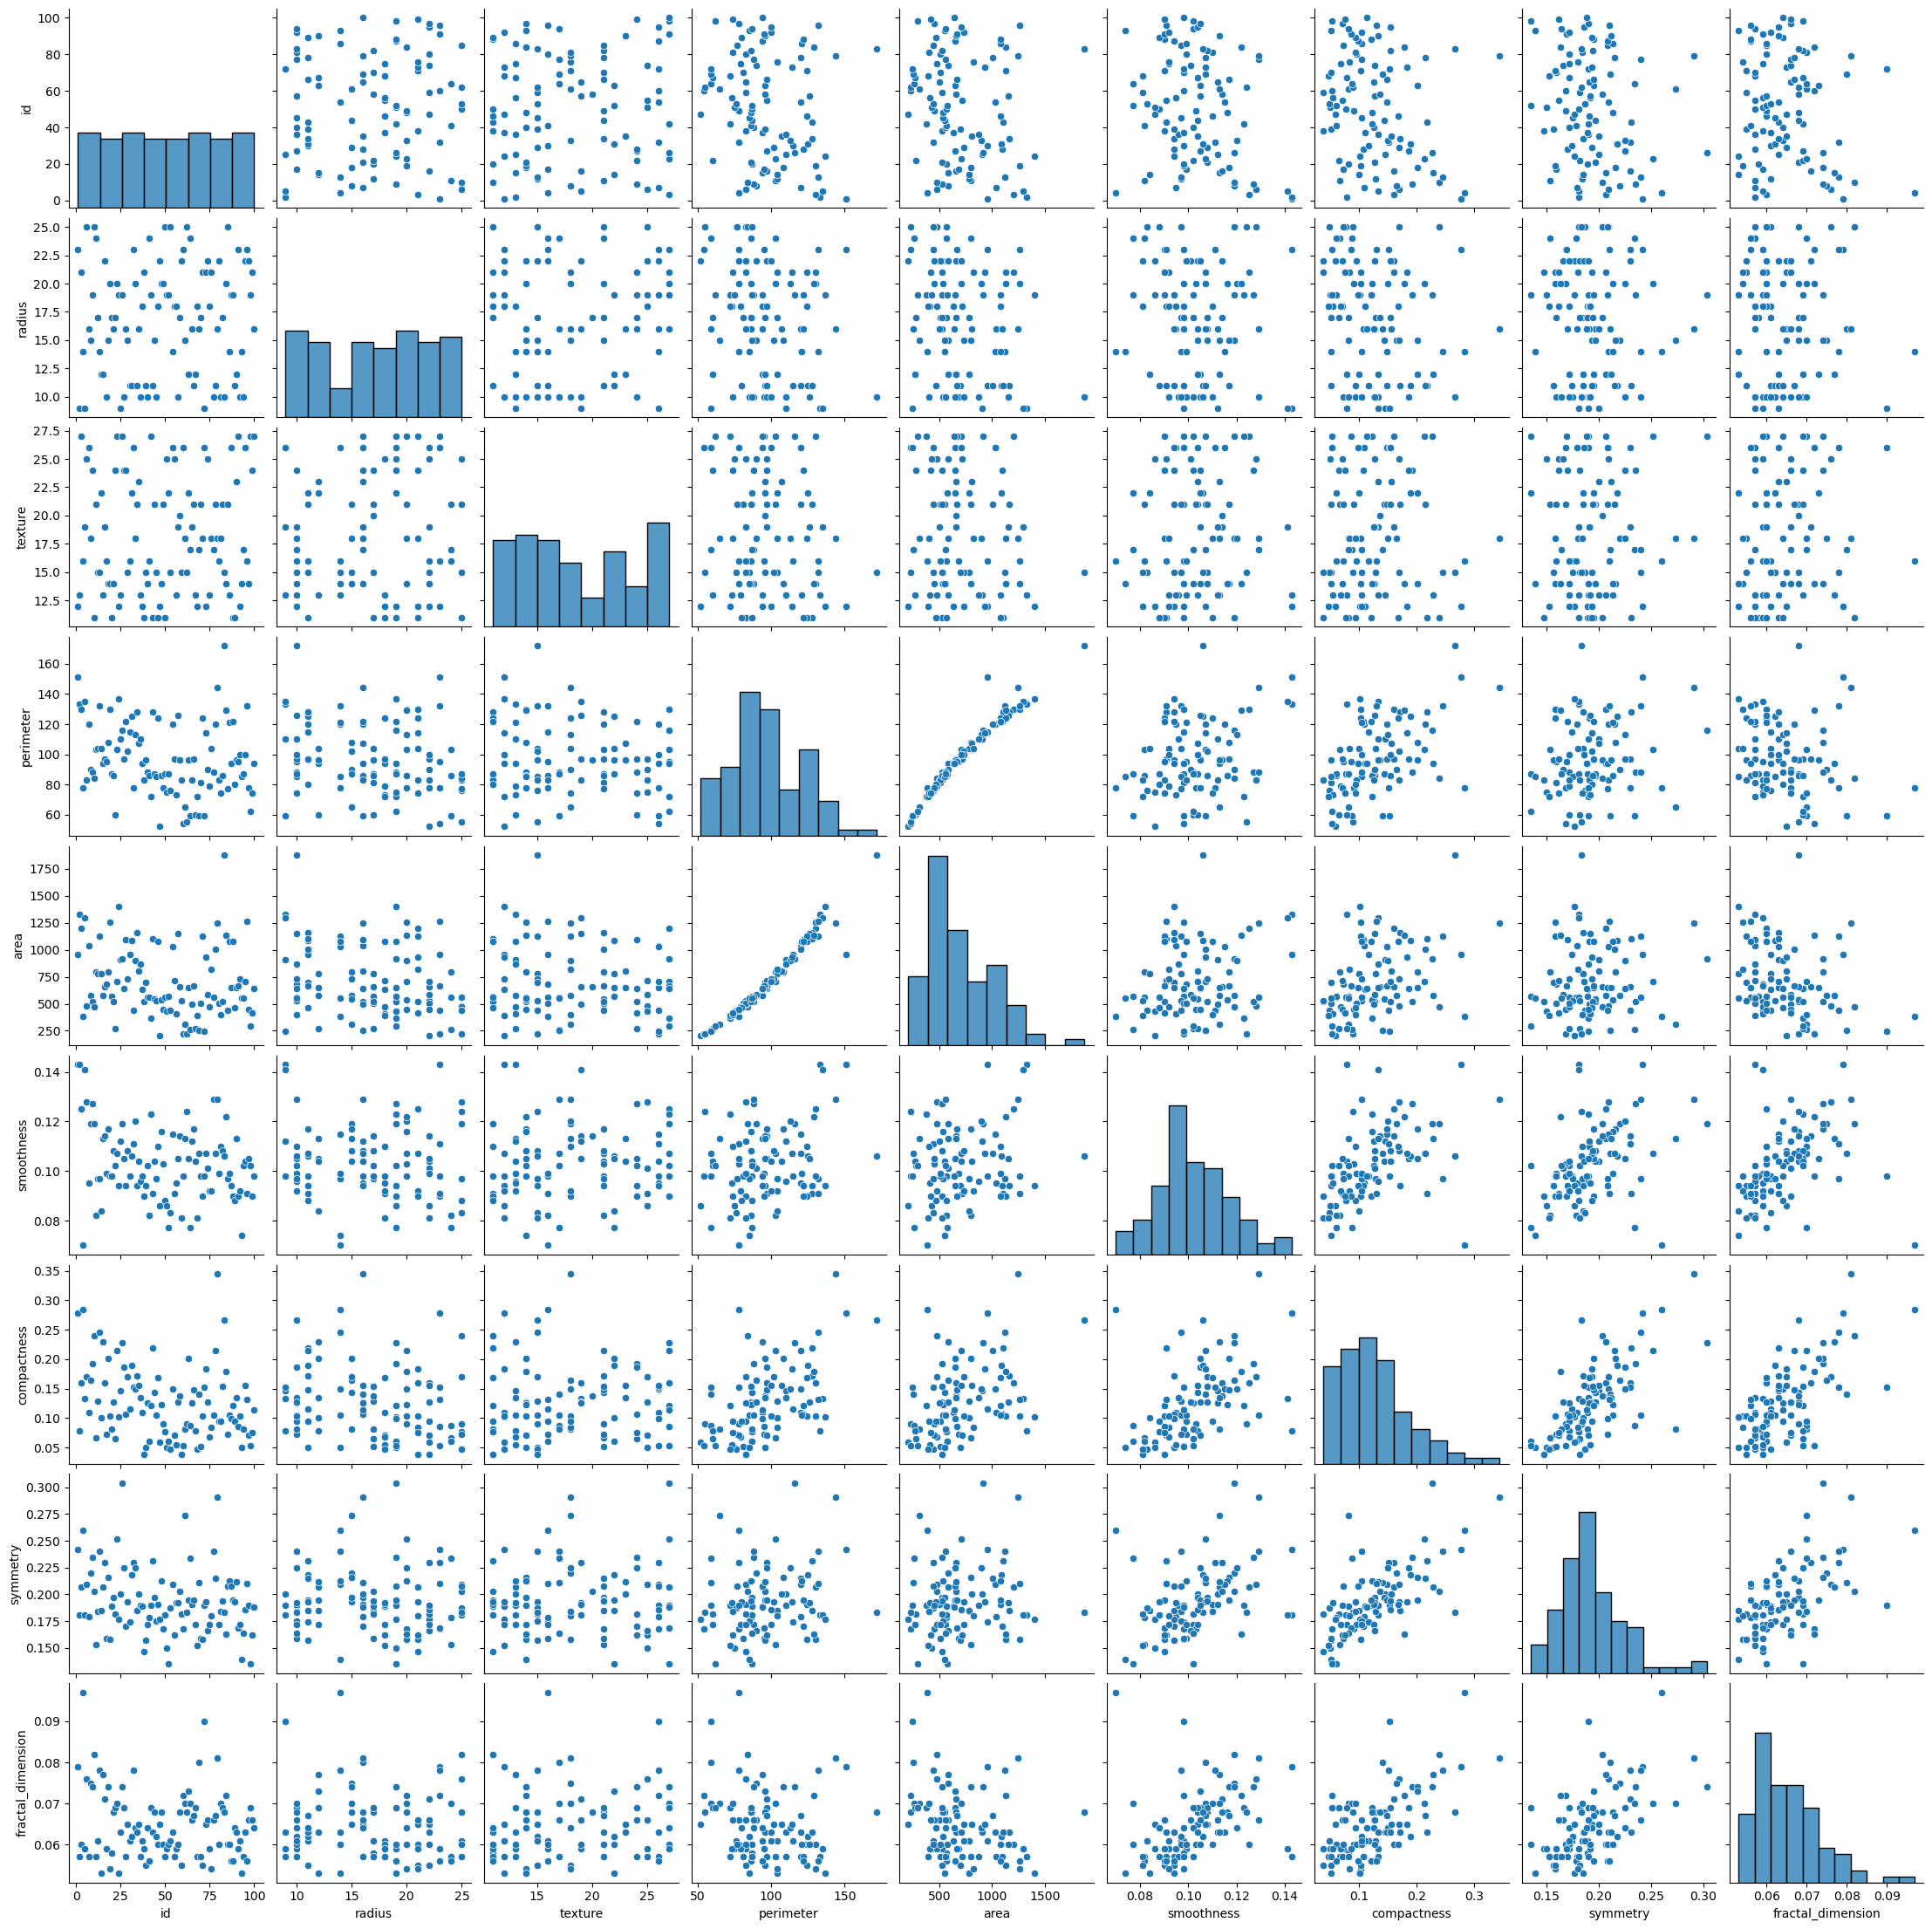

In [6]:
sns.pairplot(data=df)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [9]:
le = LabelEncoder()
df["diagnosis_result_encoded"]  = le.fit_transform(df["diagnosis_result"])

In [10]:
df.head(5)

,id,diagnosis_result,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension,diagnosis_result_encoded
0,1,M,23,12,151,954,0.143,0.278,0.242,0.079,1
1,2,B,9,13,133,1326,0.143,0.079,0.181,0.057,0
2,3,M,21,27,130,1203,0.125,0.160,0.207,0.060,1
3,4,M,14,16,78,386,0.070,0.284,0.260,0.097,1
4,5,M,9,19,135,1297,0.141,0.133,0.181,0.059,1


In [12]:
df = df.iloc[:,2:]

In [13]:
df.head(5)

,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension,diagnosis_result_encoded
0,23,12,151,954,0.143,0.278,0.242,0.079,1
1,9,13,133,1326,0.143,0.079,0.181,0.057,0
2,21,27,130,1203,0.125,0.160,0.207,0.060,1
3,14,16,78,386,0.070,0.284,0.260,0.097,1
4,9,19,135,1297,0.141,0.133,0.181,0.059,1


In [20]:
X = df.drop("diagnosis_result_encoded",axis=1)
y = df[["diagnosis_result_encoded"]]

In [21]:
X

,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
0,23,12,151,954,0.143,0.278,0.242,0.079
1,9,13,133,1326,0.143,0.079,0.181,0.057
2,21,27,130,1203,0.125,0.160,0.207,0.060
3,14,16,78,386,0.070,0.284,0.260,0.097
4,9,19,135,1297,0.141,0.133,0.181,0.059
...,...,...,...,...,...,...,...,...
95,23,16,132,1264,0.091,0.131,0.210,0.056
96,22,14,78,451,0.105,0.071,0.190,0.066
97,19,27,62,295,0.102,0.053,0.135,0.069
98,21,24,74,413,0.090,0.075,0.162,0.066


In [22]:
y

,diagnosis_result_encoded
0,1
1,0
2,1
3,1
4,1
...,...
95,1
96,0
97,0
98,0


In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train

,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
55,18,13,73,409,0.095,0.055,0.192,0.059
88,11,11,80,466,0.088,0.094,0.193,0.064
26,10,24,97,645,0.105,0.187,0.225,0.069
42,11,11,128,1104,0.091,0.219,0.231,0.063
69,17,21,81,503,0.098,0.052,0.159,0.057
...,...,...,...,...,...,...,...,...
60,15,18,65,312,0.113,0.081,0.274,0.070
71,9,26,59,244,0.098,0.153,0.190,0.090
14,12,13,94,578,0.113,0.229,0.207,0.077
92,14,14,85,552,0.074,0.051,0.139,0.053


In [25]:
X_test

,radius,texture,perimeter,area,smoothness,compactness,symmetry,fractal_dimension
83,20,14,129,1132,0.122,0.179,0.163,0.072
53,14,26,120,1033,0.115,0.149,0.209,0.063
70,21,18,124,1130,0.090,0.103,0.158,0.055
45,18,11,124,1076,0.110,0.169,0.191,0.060
44,10,15,85,532,0.097,0.105,0.175,0.062
39,10,14,88,559,0.102,0.126,0.172,0.064
22,20,27,103,704,0.107,0.214,0.252,0.070
80,10,18,74,402,0.110,0.094,0.184,0.070
10,24,21,103,798,0.082,0.067,0.153,0.057
0,23,12,151,954,0.143,0.278,0.242,0.079


In [26]:
y_train

,diagnosis_result_encoded
55,0
88,0
26,1
42,1
69,0
...,...
60,0
71,0
14,1
92,0


In [27]:
y_test

,diagnosis_result_encoded
83,1
53,1
70,1
45,1
44,1
39,1
22,1
80,0
10,1
0,1


In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
X_train

array([[ 2.11318344e-01, -9.66736489e-01, -8.91582441e-01,
        -8.05947615e-01, -4.65416275e-01, -1.08266423e+00,
        -2.30982851e-02, -6.69422749e-01],
       [-1.28663448e+00, -1.35343108e+00, -5.82618229e-01,
        -6.22786831e-01, -9.65671772e-01, -4.40109085e-01,
         9.89926506e-03, -6.76944353e-02],
       [-1.50062774e+00,  1.16008379e+00,  1.67723430e-01,
        -4.75977036e-02,  2.49234435e-01,  1.09213780e+00,
         1.06582087e+00,  5.34033879e-01],
       [-1.28663448e+00, -1.35343108e+00,  1.53599351e+00,
         1.42732861e+00, -7.51276559e-01,  1.61936253e+00,
         1.26380617e+00, -1.88040098e-01],
       [-2.67491575e-03,  5.80041893e-01, -5.38480484e-01,
        -5.03892989e-01, -2.51021062e-01, -1.13209155e+00,
        -1.11201744e+00, -9.10114075e-01],
       [ 1.06729138e+00,  1.93347298e-01,  1.67723430e-01,
        -2.61084450e-03,  8.92420074e-01,  6.47291929e-01,
         1.23080862e+00,  7.74725204e-01],
       [ 1.49527790e+00, -3.866945

In [32]:
X_train

array([[ 2.11318344e-01, -9.66736489e-01, -8.91582441e-01,
        -8.05947615e-01, -4.65416275e-01, -1.08266423e+00,
        -2.30982851e-02, -6.69422749e-01],
       [-1.28663448e+00, -1.35343108e+00, -5.82618229e-01,
        -6.22786831e-01, -9.65671772e-01, -4.40109085e-01,
         9.89926506e-03, -6.76944353e-02],
       [-1.50062774e+00,  1.16008379e+00,  1.67723430e-01,
        -4.75977036e-02,  2.49234435e-01,  1.09213780e+00,
         1.06582087e+00,  5.34033879e-01],
       [-1.28663448e+00, -1.35343108e+00,  1.53599351e+00,
         1.42732861e+00, -7.51276559e-01,  1.61936253e+00,
         1.26380617e+00, -1.88040098e-01],
       [-2.67491575e-03,  5.80041893e-01, -5.38480484e-01,
        -5.03892989e-01, -2.51021062e-01, -1.13209155e+00,
        -1.11201744e+00, -9.10114075e-01],
       [ 1.06729138e+00,  1.93347298e-01,  1.67723430e-01,
        -2.61084450e-03,  8.92420074e-01,  6.47291929e-01,
         1.23080862e+00,  7.74725204e-01],
       [ 1.49527790e+00, -3.866945

In [34]:
model = SVC(kernel="rbf")
model.fit(X_train,y_train)

C:\Users\conte\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [41]:
y_pred = model.predict(X_test)

In [42]:
model.score(X_test,y_test)*100

75.0

In [43]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\Classification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.75
\Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.25      0.29         4
           1       0.82      0.88      0.85        16

    accuracy                           0.75        20
   macro avg       0.58      0.56      0.57        20
weighted avg       0.73      0.75      0.74        20


Confusion Matrix:
 [[ 1  3]
 [ 2 14]]
